# CMB TT Spectrum Calculation (Simplified)

This notebook demonstrates how to compute the CMB temperature power spectrum using DISCO-EB's modular CMB functions.

In [ ]:
import jax
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_platform_name', 'gpu')
import jax.numpy as jnp
import matplotlib.pyplot as plt
from functools import partial

# Check JAX backend
try:
    backend = jax.extend.backend.get_backend()
    print(f"JAX backend: {backend.platform}")
except AttributeError:
    print(f"JAX backend: {jax.default_backend()}")

print(f"Devices: {jax.devices()}")

## Import DISCO-EB modules

In [ ]:
from discoeb.background import evolve_background, compute_background_quantities
from discoeb.perturbations import evolve_perturbations_batched, compute_time_derivatives
from discoeb.cmb import (
    extract_perturbations,
    compute_neutrino_perturbations,
    compute_metric_perturbations,
    compute_source_function,
    compute_theta_ell,
    compute_Cell,
    compute_Dell,
    compute_visibility_functions,
)

## Set cosmological parameters

In [ ]:
cosmo_params = {}
cosmo_params['Omegam']  = 0.3099            # Total matter density
cosmo_params['Omegab']  = 0.0488911         # Baryon density
cosmo_params['w_DE_0']  = -0.99             # Dark energy EOS today
cosmo_params['w_DE_a']  = 0.0               # Dark energy EOS derivative
cosmo_params['cs2_DE']  = 1.0               # Dark energy sound speed squared
cosmo_params['Omegak']  = 0.0               # Curvature
cosmo_params['A_s']     = 2.1064e-09        # Primordial amplitude
cosmo_params['n_s']     = 0.96822           # Spectral index
cosmo_params['H0']      = 67.742            # Hubble constant (km/s/Mpc)
cosmo_params['Tcmb']    = 2.7255            # CMB temperature (K)
cosmo_params['YHe']     = 0.248             # Helium mass fraction
cosmo_params['Neff']    = 2.046             # Effective relativistic species
cosmo_params['Nmnu']    = 1                 # Massive neutrino species
cosmo_params['mnu']     = 0.06              # Neutrino mass (eV)
cosmo_params['k_p']     = 0.05              # Pivot scale (1/Mpc)

# Wavenumber sampling
nmodes = 512
kmin   = 1e-4
kmax   = 1.0

## Compute background evolution

In [ ]:
param = cosmo_params.copy()
print("Computing background evolution...")
param = evolve_background(param=param, thermo_module='RECFAST', num_thermo=1024)
print(f"Background complete. Thermal history has {len(param['aexp'])} points")

## Compute perturbation evolution

In [ ]:
# Dense sampling near recombination, coarser at late times
aexp_out = jnp.geomspace(3e-4, 5e-3, 256, endpoint=False)
aexp_out = jnp.append(aexp_out, jnp.geomspace(5e-3, 1.0, 64))

print(f"Computing perturbations for {nmodes} k-modes at {len(aexp_out)} output times...")
yout, kmodes, param = evolve_perturbations_batched(
    param=param, 
    kmin=kmin, 
    kmax=kmax, 
    num_k=nmodes, 
    aexp_out=aexp_out,
    rtol=1e-4, 
    atol=1e-4,
    return_full=True,
    dologk=True,
)

print(f"Perturbations computed. Output shape: {yout.shape}")

## Compute time derivatives

In [ ]:
# Compute time derivatives by re-evaluating the ODE system
# This is needed for the CMB source function calculation
print("Computing time derivatives...")
tau = param['tau_out']
# Convert to Python integers for static args
lmaxg = int(param['lmaxg'])
lmaxgp = int(param['lmaxgp'])
lmaxr = int(param['lmaxr'])
lmaxnu = int(param['lmaxnu'])
nqmax = int(param['nqmax'])
yprime = compute_time_derivatives(yout, tau, kmodes, param, lmaxg, lmaxgp, lmaxr, lmaxnu, nqmax)

print(f"Derivatives computed. Shape: {yprime.shape}")

## Compute CMB source function

We'll compute the source function in several steps:
1. Extract perturbations from the state vector
2. Compute background quantities and visibility functions
3. Compute neutrino perturbations
4. Compute metric perturbations
5. Compute the four source terms (ISW, Sachs-Wolfe, Doppler, Polarization)

In [ ]:
print("Computing CMB source function components...")

# 1. Extract perturbations from state vector
lmaxg = param['lmaxg']
lmaxgp = param['lmaxgp']
lmaxr = param['lmaxr']
nqmax = param['nqmax']
perturbations = extract_perturbations(yout, yprime, lmaxg, lmaxgp, lmaxr)

# 2. Compute background quantities (neutrino density, dark energy density, EOS)
background_quantities = compute_background_quantities(aexp_out, param)

# 3. Compute visibility functions (g, g', g'', opacity, optical depth)
tau = param['tau_of_a_spline'].evaluate(aexp_out)
visibility_functions = compute_visibility_functions(tau, param)

print("  - Perturbations extracted")
print("  - Background quantities computed")
print("  - Visibility functions computed")

In [ ]:
# 4. Compute neutrino perturbations
print("Computing neutrino perturbations...")
neutrinos = compute_neutrino_perturbations(
    yout, yprime, aexp_out, param, int(nqmax), int(perturbations['iq0'])
)
print("  - Neutrino perturbations computed")

In [ ]:
# 5. Compute metric perturbations from Einstein equations
print("Computing metric perturbations...")
metric = compute_metric_perturbations(
    perturbations, neutrinos, background_quantities, param, kmodes, aexp_out
)
print("  - Metric perturbations computed")

In [ ]:
# 6. Compute the four CMB source terms
print("Computing CMB source terms...")
source_results = compute_source_function(
    perturbations, metric, visibility_functions, yout, yprime, kmodes, lmaxg, lmaxgp, tau
)

S = source_results['S']      # Total source function
S1 = source_results['S1']    # ISW (Integrated Sachs-Wolfe)
S2 = source_results['S2']    # Sachs-Wolfe
S3 = source_results['S3']    # Doppler
S4 = source_results['S4']    # Polarization

print(f"\nSource function computed. Shape: {S.shape}")
print("  - S1 (ISW): Time-varying gravitational potentials")
print("  - S2 (Sachs-Wolfe): Temperature + potential at last scattering")
print("  - S3 (Doppler): Bulk motion of baryons")
print("  - S4 (Polarization): E-mode coupling")

## Visualize source function components

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
ax.pcolormesh(kmodes, aexp_out, S1.T, shading='auto')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('k [Mpc$^{-1}$]')
ax.set_ylabel('a')
ax.set_title('S1: ISW term')

ax = axes[0, 1]
ax.pcolormesh(kmodes, aexp_out, S2.T, shading='auto')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('k [Mpc$^{-1}$]')
ax.set_ylabel('a')
ax.set_title('S2: Sachs-Wolfe term')

ax = axes[1, 0]
ax.pcolormesh(kmodes, aexp_out, S3.T, shading='auto')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('k [Mpc$^{-1}$]')
ax.set_ylabel('a')
ax.set_title('S3: Doppler term')

ax = axes[1, 1]
ax.pcolormesh(kmodes, aexp_out, S4.T, shading='auto')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('k [Mpc$^{-1}$]')
ax.set_ylabel('a')
ax.set_title('S4: Polarization term')

plt.tight_layout()
plt.show()

## Line-of-sight integration

Integrate the source function with spherical Bessel functions to get multipole moments:
$$\Theta_\ell(k) = \int_0^{\tau_0} S(k,\tau) \, j_\ell(k(\tau_0-\tau)) \, d\tau$$

In [ ]:
# Line-of-sight integration parameters
ellmax = 2500
nk_fine = 512
chunk_size = 64
k_chunk_size = 64

# Get conformal time today
tau0 = param['tau_of_a_spline'].evaluate(1.0)

print(f"Computing multipole moments Θ_ℓ(k) up to ℓ={ellmax}...")
theta_ell, kmodes_fine = compute_theta_ell(
    ellmax=ellmax,
    kmodes=kmodes,
    tau=tau,
    S=S,
    tau0=tau0,
    nk_fine=nk_fine,
    chunk_size=chunk_size,
    k_chunk_size=k_chunk_size
)
print(f"Multipole moments computed. Shape: {theta_ell.shape}")

In [ ]:
print(f"Computing C_ℓ angular power spectrum...")
Cell = compute_Cell(
    theta_ell=theta_ell,
    kmodes_fine=kmodes_fine,
    n_s=param['n_s'],
    k_p=param['k_p']
)
print(f"C_ℓ computed. Shape: {Cell.shape}")

In [ ]:
ell_disco, Dell_disco = compute_Dell(Cell, A_s=param['A_s'], Tcmb=param['Tcmb'], ellmax=ellmax)

## Quick function

In [1]:
import jax
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_platform_name', 'gpu')
from discoeb.cmb import compute_Cell_spectrum_from_cosmo_params, compute_Dell

# Check JAX backend
try:
    backend = jax.extend.backend.get_backend()
    print(f"JAX backend: {backend.platform}")
except AttributeError:
    print(f"JAX backend: {jax.default_backend()}")

print(f"Devices: {jax.devices()}")

cosmo_params = {}
cosmo_params['Omegam']  = 0.3099            # Total matter density
cosmo_params['Omegab']  = 0.0488911         # Baryon density
cosmo_params['w_DE_0']  = -0.99             # Dark energy EOS today
cosmo_params['w_DE_a']  = 0.0               # Dark energy EOS derivative
cosmo_params['cs2_DE']  = 1.0               # Dark energy sound speed squared
cosmo_params['Omegak']  = 0.0               # Curvature
cosmo_params['A_s']     = 2.1064e-09        # Primordial amplitude
cosmo_params['n_s']     = 0.96822           # Spectral index
cosmo_params['H0']      = 67.742            # Hubble constant (km/s/Mpc)
cosmo_params['Tcmb']    = 2.7255            # CMB temperature (K)
cosmo_params['YHe']     = 0.248             # Helium mass fraction
cosmo_params['Neff']    = 2.046             # Effective relativistic species
cosmo_params['Nmnu']    = 1                 # Massive neutrino species
cosmo_params['mnu']     = 0.06              # Neutrino mass (eV)
cosmo_params['k_p']     = 0.05              # Pivot scale (1/Mpc)

param = cosmo_params.copy()
ellmax = 2500
Cell, param = compute_Cell_spectrum_from_cosmo_params(param, ellmax=ellmax, nmodes=128)
ell_disco, Dell_disco = compute_Dell(Cell, A_s=param['A_s'], Tcmb=param['Tcmb'])
ell_disco.block_until_ready()

/home/user/git/DISCO-EB/.venv/lib/python3.12/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


JAX backend: gpu
Devices: [CudaDevice(id=0)]


Array([   2,    3,    4, ..., 2498, 2499, 2500], dtype=int64)

## Compare with CAMB

In [2]:
import camb
import jax.numpy as jnp

params = cosmo_params.copy()


cpars = camb.CAMBparams()

# Cosmological parameters
h = params['H0'] / 100.0
cpars.set_cosmology(
    H0=params['H0'],
    ombh2=params['Omegab'] * h**2,
    omch2=(params['Omegam'] - params['Omegab']) * h**2,
    omk=params['Omegak'],
    tau=0.0,  # Reionization optical depth
    mnu=params['mnu'],
    num_massive_neutrinos=params['Nmnu'],
    nnu=params['Neff'] + params['Nmnu'],
    YHe=params['YHe'],
    TCMB=params['Tcmb'],
)

# Dark energy equation of state
cpars.DarkEnergy.w = params['w_DE_0']
cpars.DarkEnergy.wa = params['w_DE_a']

# Initial power spectrum
cpars.InitPower.As = params['A_s']  # Amplitude of scalar perturbations
cpars.InitPower.ns = params['n_s']  # Scalar spectral index
cpars.InitPower.kpivot = params['k_p']  # Pivot scale in Mpc^-1

# Accuracy parameters
cpars.set_for_lmax(ellmax)
cpars.set_accuracy(lSampleBoost=50.0)  # compute all ells

results = camb.get_results(cpars)
powers = results.get_cmb_power_spectra(cpars, CMB_unit='K')

ell_camb = jnp.arange(2, powers['unlensed_total'].shape[0])
Dell_camb = powers['unlensed_total'][2:, 0] * 1e12

## Plot comparison

/tmp/ipykernel_32704/3806544429.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


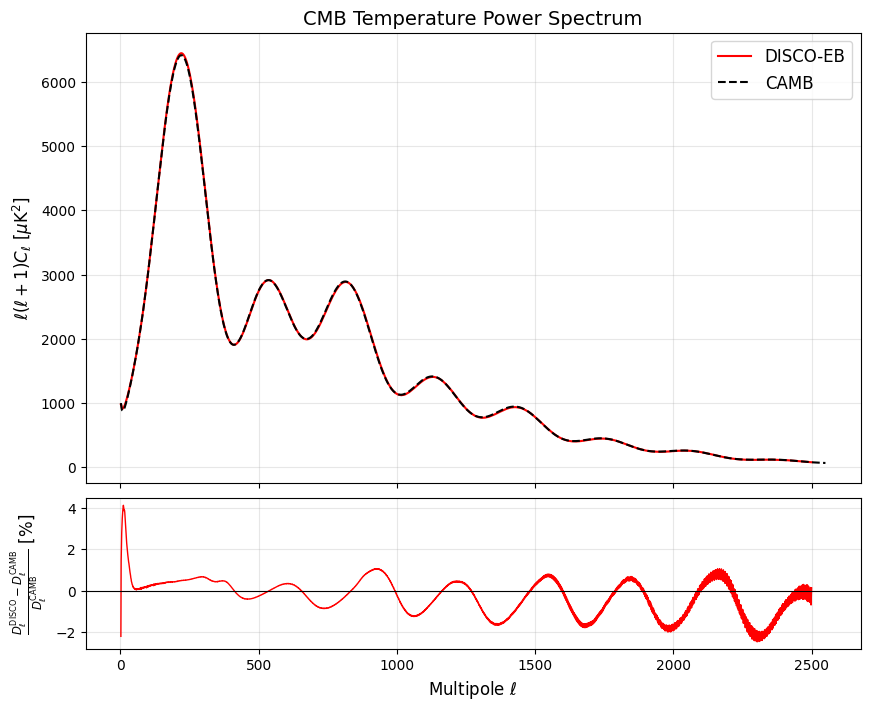

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Interpolate CAMB onto DISCO-EB ell grid for residual computation
Dell_camb_interp = np.interp(ell_disco, ell_camb, Dell_camb)
residual = (Dell_disco - Dell_camb_interp) / Dell_camb_interp * 100  # percent

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(10, 8), sharex=True,
                                      gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

# --- Top: power spectra ---
ax_top.plot(ell_disco, Dell_disco, 'r-', label='DISCO-EB', linewidth=1.5)
ax_top.plot(ell_camb, Dell_camb, 'k--', label='CAMB', linewidth=1.5)
ax_top.legend(fontsize=12)
ax_top.set_ylabel(r'$\ell(\ell+1)C_\ell$ [$\mu$K$^2$]', fontsize=12)
ax_top.set_title('CMB Temperature Power Spectrum', fontsize=14)
ax_top.grid(True, alpha=0.3)

# --- Bottom: residuals ---
ax_bot.plot(ell_disco, residual, 'r-', linewidth=1.0)
ax_bot.axhline(0, color='k', linewidth=0.8, linestyle='-')
ax_bot.set_xlabel(r'Multipole $\ell$', fontsize=12)
ax_bot.set_ylabel(r'$\frac{D_\ell^{\rm DISCO} - D_\ell^{\rm CAMB}}{D_\ell^{\rm CAMB}}$ [%]', fontsize=12)
ax_bot.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()